# Cross-modal retrieval

Retrieves a cell's subcellular gene pattern (latent representation) from its morphology, and its morphology and its spatial context from its gene pattern, using the representations a trained SVC already produces.

Reads

- `test_xenium_mouse_brain.npz`, `gene_names.txt`, `gene2vec_weight_xenium_mouse_brain.npy`
- `checkpoint_Xenium_mouse_brain.pth` — the released checkpoint, from `../../../checkpoints`

Writes

- nothing; the representations are held in memory

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

warnings.filterwarnings('ignore')

SVC_ROOT = Path(os.environ.get('SVC_ROOT', '../../..'))   # github.com/aster-ww/SVC
sys.path.insert(0, str(SVC_ROOT))
from svc.losses import BACKGROUND_PIXELS
from svc.model import SVC
from svc.retrieval import (CrossModalRetriever, gene_pattern_repr, morphology_repr,
                           spatial_context_repr)

DATA_ROOT = Path(os.environ.get('SVC_DATA_ROOT', '../../../data'))
DATA_DIR = DATA_ROOT / 'xenium_mouse_brain'
CKPT_DIR = Path('../../../checkpoints')

## Data

Three cell types of the second tissue section — DG, Endo and Oligo — and the 100 most highly
expressed genes.

In [2]:
TYPES = ['DG', 'Endo', 'Oligo']
TOP_GENES = 100
K_SCALES = (4, 16, 64)
K_CONTEXT = 20

test = np.load(DATA_DIR / 'test_xenium_mouse_brain.npz', allow_pickle=True)
gene_names = np.loadtxt(DATA_DIR / 'gene_names.txt', dtype=str)
counts_all = test['data_ori']
identity_all = test['identity_label'].astype(np.float32)
cell_type_all = test['identity'].astype(str)

foreground = np.ones((12, 12), bool)
for row, column in BACKGROUND_PIXELS:
    foreground[row, column] = False
full_expr_all = (counts_all * foreground.reshape(1, 1, 12, 12)).sum((-1, -2)).astype(np.float32)
cell_median = float(np.median(counts_all.reshape(len(counts_all), -1).sum(1)))

sub = np.flatnonzero(np.isin(cell_type_all, TYPES))
cell_type = cell_type_all[sub]
counts = counts_all[sub].astype(np.float32)
cell_mask = test['cell_morphology'][sub].astype(np.float32)
nuclear_mask = test['nuclear_morphology'][sub].astype(np.float32)
identity = identity_all[sub]
nb_idx = test['nb_idx'][sub].astype(np.int64)
nb_dist = test['nb_dist'][sub].astype(np.float32)[:, :max(K_SCALES)]
sn_expr = full_expr_all[nb_idx][:, :max(K_SCALES)]
tau = [float(np.median(nb_dist[:, k - 1])) for k in K_SCALES]

genes = np.argsort(-full_expr_all[sub].mean(0))[:TOP_GENES]
print('%d cells | %s' % (len(sub), '  '.join('%s %d' % (t, (cell_type == t).sum()) for t in TYPES)))
print('most expressed genes: %s ...' % ', '.join(gene_names[genes][:6]))

9863 cells | DG 2504  Endo 3613  Oligo 3746
most expressed genes: Slc17a7, Nrn1, Clmn, Prox1, Rims3, Epha4 ...


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gene2vec_weight = torch.from_numpy(
    np.load(DATA_DIR / 'gene2vec_weight_xenium_mouse_brain.npy')).float()
checkpoint = torch.load(CKPT_DIR / 'checkpoint_Xenium_mouse_brain.pth', map_location=device)
state = {k.replace('module.', ''): v for k, v in checkpoint['model_state_dict'].items()}

model = SVC(gene2vec_weight=gene2vec_weight, n_genes_for_sn=len(gene_names),
            k_scales=K_SCALES, tau_init_per_scale=tau,
            cell_morphology=True, nuclear_morphology=True, use_cell_identity=True,
            cell_identity_dim=identity.shape[1], emb_dropout=0.0).to(device)
model.load_state_dict(state, strict=True)
model.eval()
model.set_tau_per_scale(tau)
model.set_cell_median(cell_median)
print('loaded epoch %d' % checkpoint['best_epoch'])

loaded epoch 149


In [4]:
morphology = morphology_repr(model, cell_mask, nuclear_mask)
gene_pattern = gene_pattern_repr(model, counts, sn_expr, nb_dist, cell_mask, nuclear_mask,
                                 identity, genes=genes, cell_median=cell_median,
                                 ablate=('morphology', 'identity'))
intrinsic = gene_pattern_repr(model, counts, sn_expr, nb_dist, cell_mask, nuclear_mask,
                              identity, genes=genes, cell_median=cell_median,
                              ablate=('morphology', 'spatial_context', 'identity'))
context = spatial_context_repr(nb_idx, identity_all, k=K_CONTEXT)
print('morphology %s | gene pattern %s | spatial context %s'
      % (morphology.shape, gene_pattern.shape, context.shape))

morphology (9863, 768) | gene pattern (9863, 100, 384) | spatial context (9863, 42)


## Morphology to gene pattern

The target gene-pattern embedding is extracted after ablating morphology and cell identity. A
ridge probe is fitted from the query to the target on 70% of the cells and each held-out query
is matched against all held-out targets by cosine similarity. A retrieved cell counts as correct
either when it is the query cell itself, or when it is among the five cells whose measured
transcript patterns are most similar to the query's.


held out 2960 of 9863 cells | ridge penalty 1000
AUROC  self 0.734  top-5 similar 0.688


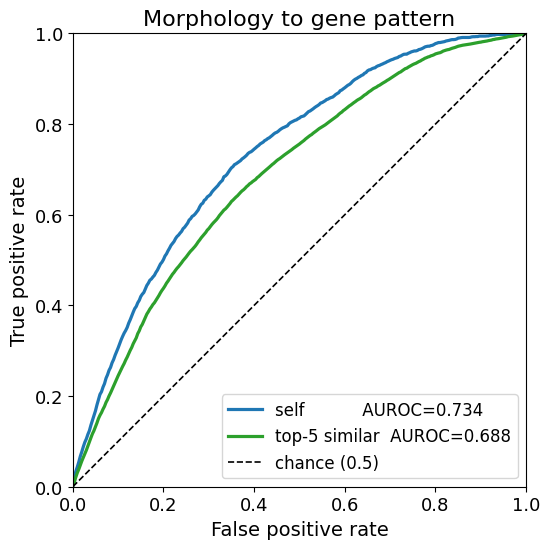

In [5]:
TOP_K = 5
COLORS = {'self': '#1f77b4', 'top-5 similar': '#2ca02c'}


def plot_roc(ax, curves, title):
    for label, (grid, tpr, auroc) in curves.items():
        ax.plot(grid, tpr, color=COLORS[label], lw=2.3, label='%-14s AUROC=%.3f' % (label, auroc))
    ax.plot([0, 1], [0, 1], '--', color='k', lw=1.2, label='chance (0.5)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel('False positive rate', fontsize=14)
    ax.set_ylabel('True positive rate', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=12, loc='lower right')


forward = CrossModalRetriever().fit(morphology, gene_pattern, stratify=cell_type)
forward_roc = {'self': forward.roc(),
               'top-5 similar': forward.roc(relevance='similarity',
                                            ground_truth=counts[:, genes], top_k=TOP_K)}
print('held out %d of %d cells | ridge penalty %g'
      % (len(forward.held_out_idx_), len(cell_type), forward.alpha_))
print('AUROC  %s' % '  '.join('%s %.3f' % (k, v[2]) for k, v in forward_roc.items()))

fig, ax = plt.subplots(figsize=(5.8, 5.6))
plot_roc(ax, forward_roc, 'Morphology to gene pattern')
plt.tight_layout()
plt.show()

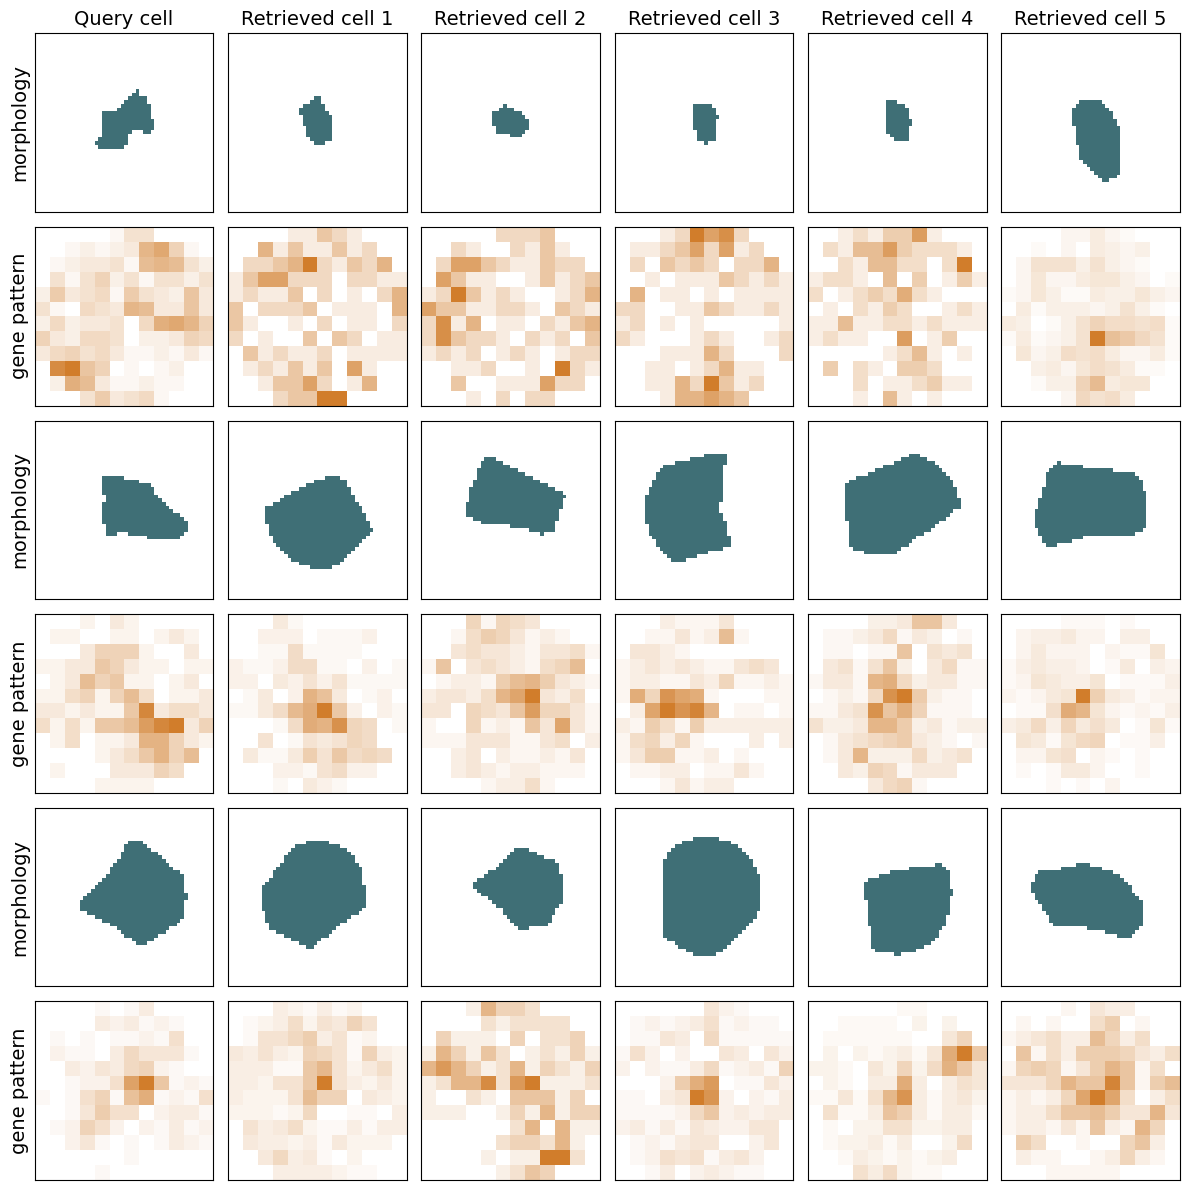

In [6]:
MASK_CMAP = ListedColormap(['white', '#3f6f76'])
PATTERN_CMAP = LinearSegmentedColormap.from_list('pattern', ['white', '#D17D2B'])
background = ~foreground
ROWS = ('morphology', 'gene pattern')


def panel(ax, cell, kind):
    if kind == 'morphology':
        ax.imshow(cell_mask[cell], cmap=MASK_CMAP)
    else:
        ax.imshow(np.where(background, np.nan, counts[cell][genes].sum(0)), cmap=PATTERN_CMAP)
    ax.set_xticks([])
    ax.set_yticks([])


held_type = cell_type[forward.held_out_idx_]
retrieved = forward.retrieve(top_k=TOP_K + 1)
queries = [np.flatnonzero(held_type == cell)[position]
           for cell, position in zip(TYPES, [23, 0, 0])]

fig, ax = plt.subplots(2 * len(queries), 1 + TOP_K,
                       figsize=(2.0 * (1 + TOP_K), 2.0 * 2 * len(queries)))
for block, query in enumerate(queries):
    order = retrieved[query]
    order = order[order != query][:TOP_K]
    for offset, kind in enumerate(ROWS):
        axis = ax[2 * block + offset]
        axis[0].set_ylabel(kind, fontsize=14)
        for column, row in enumerate([query, *order]):
            panel(axis[column], forward.held_out_idx_[row], kind)
            if block == 0 and offset == 0:
                axis[column].set_title('Query cell' if column == 0
                                       else 'Retrieved cell %d' % column, fontsize=14)
plt.tight_layout()
plt.show()

## Gene pattern to morphology and spatial context

Gene-pattern embeddings, extracted after ablating morphology, spatial-context and cell-identity
information, are used to retrieve two types of cell-level context: cell and nuclear morphology,
and spatial neighborhood composition.

Gene pattern to morphology       ridge penalty 0.1      self 0.744  top-5 similar 0.731
Gene pattern to spatial context  ridge penalty 100      self 0.895  top-5 similar 0.900


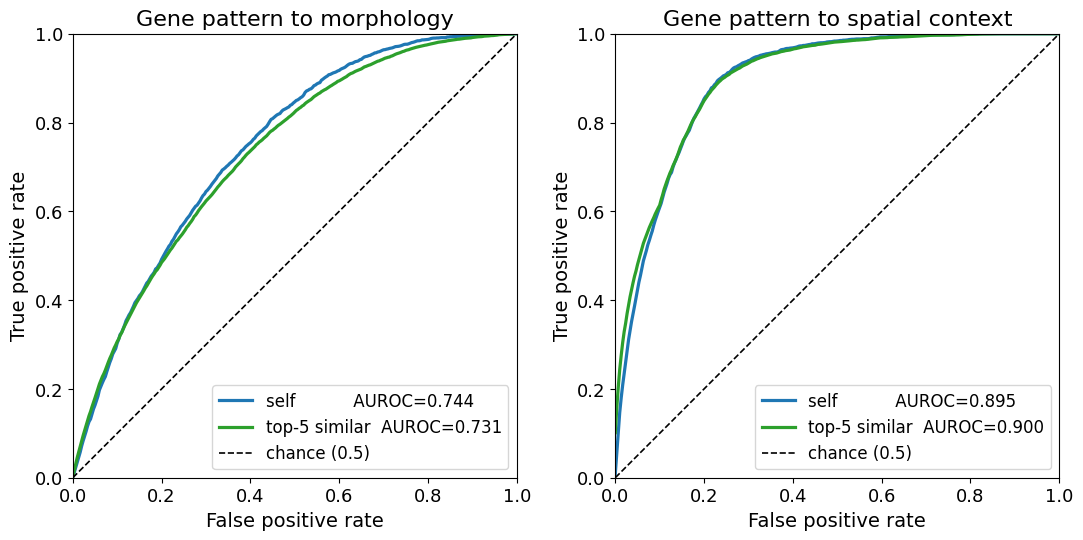

In [7]:
reverse_morphology = CrossModalRetriever().fit(intrinsic, morphology, stratify=cell_type)
reverse_context = CrossModalRetriever().fit(intrinsic, context, stratify=cell_type,
                                            pca_target=False)
measured_morphology = np.concatenate(
    [cell_mask.reshape(len(cell_mask), -1), nuclear_mask.reshape(len(nuclear_mask), -1)], axis=1)

reverse_roc = []
for retriever, truth, title in [(reverse_morphology, measured_morphology,
                                 'Gene pattern to morphology'),
                                (reverse_context, context, 'Gene pattern to spatial context')]:
    curves = {'self': retriever.roc(),
              'top-5 similar': retriever.roc(relevance='similarity', ground_truth=truth,
                                             top_k=TOP_K)}
    reverse_roc.append((curves, title))
    print('%-32s ridge penalty %-8g %s'
          % (title, retriever.alpha_, '  '.join('%s %.3f' % (k, v[2]) for k, v in curves.items())))

fig, ax = plt.subplots(1, 2, figsize=(11, 5.3))
for axis, (curves, title) in zip(ax, reverse_roc):
    plot_roc(axis, curves, title)
plt.tight_layout()
plt.show()